# INTRODUCTION

The objective is to analyze hotel booking data, identify factors that influence booking cancellations, and generate business insights before building predictive models.

In [1]:
# importing the required libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df=pd.read_csv("data/hotel_bookings.csv")

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.shape

(119390, 32)

The Dataset has a shape of 119390 rows and 32 columns 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [7]:
df.describe(include="object")

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


## Analysis  and checking of missing values and duplicate values 

In [8]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [9]:
missing_per = (df.isnull().sum() / len(df)) * 100

In [10]:
missing_per

hotel                              0.000000
is_canceled                        0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
arrival_date_day_of_month          0.000000
stays_in_weekend_nights            0.000000
stays_in_week_nights               0.000000
adults                             0.000000
children                           0.003350
babies                             0.000000
meal                               0.000000
country                            0.408744
market_segment                     0.000000
distribution_channel               0.000000
is_repeated_guest                  0.000000
previous_cancellations             0.000000
previous_bookings_not_canceled     0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                    

- we have four columns of missing values :
- 'children' with 0.003350 % missing values
- 'country' with around 0.408744 % missing values
- 'agent' with 13.686238 % missing values
- 'company' with 94.306893 % missing values

In [11]:
# Checking for duplicate rows 
dup=(df.duplicated().sum()/len(df))*100
dup

np.float64(26.797889270458164)

In [12]:
df.duplicated().sum()

np.int64(31994)

- A total of 31994 row entries are  identified as duplicated in the dataset which makes aroung 26.797 % of entries of whole dataset 

### Understanding the Target Variable

In [13]:
df['is_canceled'].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [14]:
df["is_canceled"].value_counts(normalize=True) * 100

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

It can clearly be observed that our target variable 'is_canceled' have categorical values  where 0 indicates customer  not  canceled the booking and 1 indicates the booking was canceled 

<Axes: ylabel='count'>

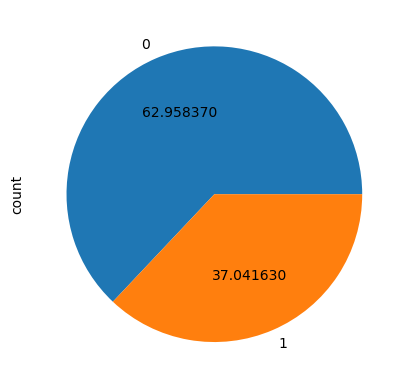

In [15]:
df['is_canceled'].value_counts().plot(kind='pie' , autopct= '%2f')

- Non-canceled bookings represent the majority of observations which is around 62.9 %, while canceled bookings form a smaller but substantial proportion nearly 37.04 % of the dataset.

### Analysing Numerical and Categorical features

In [16]:
# Analysing numerical and categorical columns 
num_col = df.select_dtypes( include= ['int64' , 'float64']).columns.tolist()
num_col
        

['is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'agent',
 'company',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

In [17]:
cat_col  = df.select_dtypes( include = ['object']).columns.tolist()
cat_col

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type',
 'reservation_status',
 'reservation_status_date']

### Analysis of Numerical Features 

### 'lead_time' column 

In [18]:
df['lead_time'].describe()

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

### Observation 
- The average lead time is approximately 104 days, while the median is 69 days, indicating that the distribution is likely right-skewed. Half of the bookings are made within 69 days of arrival, while 25% are made more than 160 days in advance. The maximum lead time of 737 days indicates the presence of very large observations that should be investigated further during outlier analysis.

<Axes: xlabel='lead_time', ylabel='Count'>

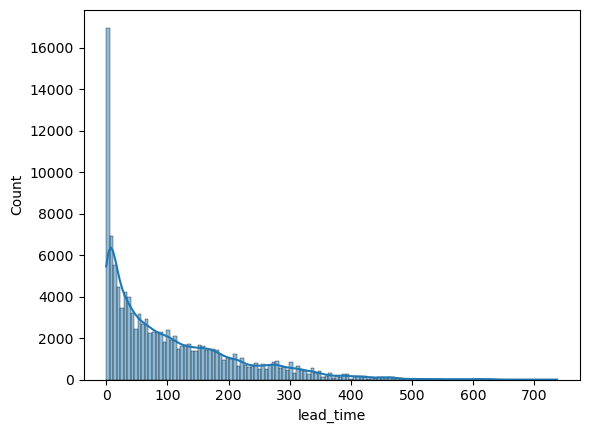

In [19]:
 sns.histplot(data = df , x= df['lead_time'] , kde = True)

### Observation 
The distribution of lead_time is strongly right-skewed. A large proportion of bookings have relatively short lead times, while the number of bookings decreases as lead time increases. However, a small number of bookings were made several hundred days before arrival, creating a long right tail. This explains why the mean lead time (104 days) is considerably higher than the median (69 days).

<Axes: xlabel='lead_time'>

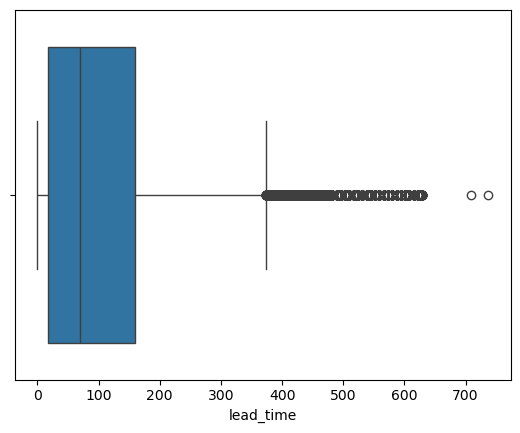

In [20]:
 sns.boxplot( data =df , x=df['lead_time'])

### Observations
The median lead time is 69 days, meaning half of the bookings were made within 69 days of arrival. The middle 50% of bookings fall between 18 and 160 days. The upper whisker extends to approximately 373 days, while observations beyond this are considered statistical outliers. The long upper tail and numerous high-value observations indicate that lead_time is strongly right-skewed

In [21]:
# analysing adults variable 
df['adults'].describe()

count    119390.000000
mean          1.856403
std           0.579261
min           0.000000
25%           2.000000
50%           2.000000
75%           2.000000
max          55.000000
Name: adults, dtype: float64

### Observations :
The average adult count is approximately 1.84, while the median is 2.00, indicating that the distribution is slight;y left-skewed. The maximum adult count is 55.00 indicates the presence of quite large adults  that should be investigated further during outlier analysis.


In [22]:
df["adults"].value_counts().sort_index()

adults
0       403
1     23027
2     89680
3      6202
4        62
5         2
6         1
10        1
20        2
26        5
27        2
40        1
50        1
55        1
Name: count, dtype: int64

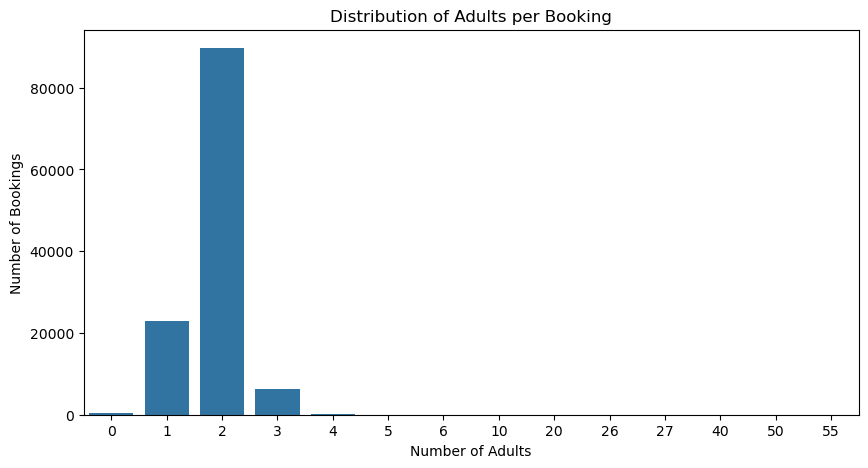

In [23]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="adults")

plt.title("Distribution of Adults per Booking")
plt.xlabel("Number of Adults")
plt.ylabel("Number of Bookings")
plt.show()

### Observation 
Most hotel bookings involve a small number of adults, with bookings containing 1–2 adults being the most common. Bookings with a larger number of adults are considerably less frequent.

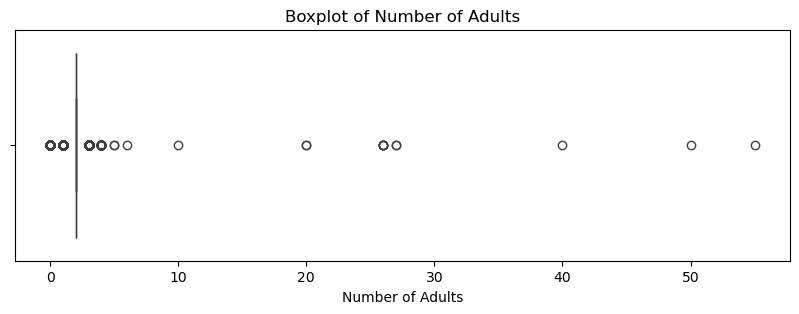

In [24]:
plt.figure(figsize=(10, 3))

sns.boxplot(data=df, x="adults")

plt.title("Boxplot of Number of Adults")
plt.xlabel("Number of Adults")
plt.show()

In [25]:
# analysing children column
df['children'].describe()

count    119386.000000
mean          0.103890
std           0.398561
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          10.000000
Name: children, dtype: float64

<Axes: xlabel='children', ylabel='count'>

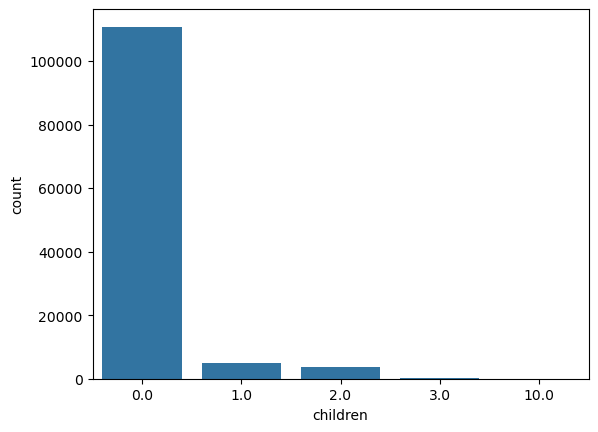

In [26]:
sns.countplot(data =df , x=df['children'])

### 'is_repeated_guest' 

In [27]:
df['is_repeated_guest'].value_counts()/len(df)*100

is_repeated_guest
0    96.808778
1     3.191222
Name: count, dtype: float64

### Observation

- The distribution of is_repeated_guest is highly imbalanced. Approximately 96.81% of bookings are from non-repeated guests, while only 3.19% are from repeated guests. Therefore, repeated guests represent a relatively small portion of the dataset. Further analysis can be performed later to determine whether being a repeated guest is associated with booking cancellation.

### 'previous_cancellations'

In [28]:
df['previous_cancellations'].value_counts()

previous_cancellations
0     112906
1       6051
2        116
3         65
24        48
11        35
4         31
26        26
25        25
6         22
19        19
5         19
14        14
13        12
21         1
Name: count, dtype: int64

<Axes: xlabel='previous_cancellations', ylabel='count'>

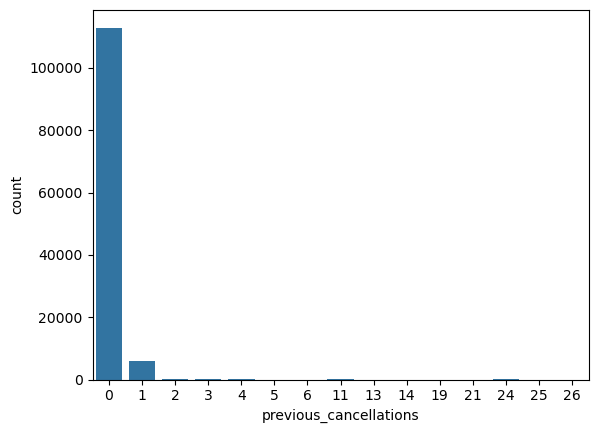

In [29]:
sns.countplot(data=df , x= df['previous_cancellations'])

### Observations 

- The previous_cancellations feature is highly concentrated at 0, indicating that the vast majority of guests had no previous booking cancellations. Only a small proportion of guests had one or more previous cancellations. The distribution is highly right-skewed, with very few guests having a large number of previous cancellations.

In [30]:
df['previous_bookings_not_canceled'].value_counts()

previous_bookings_not_canceled
0     115770
1       1542
2        580
3        333
4        229
       ...  
47         1
49         1
50         1
51         1
72         1
Name: count, Length: 73, dtype: int64

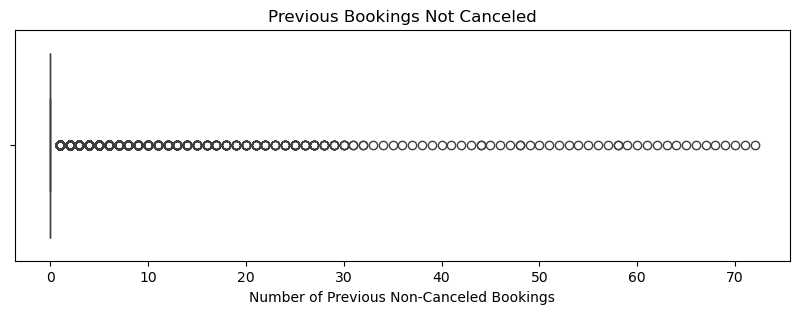

In [31]:
plt.figure(figsize=(10, 3))

sns.boxplot(data=df, x='previous_bookings_not_canceled')

plt.title('Previous Bookings Not Canceled')
plt.xlabel('Number of Previous Non-Canceled Bookings')
plt.show()

### Observations 

- The previous_bookings_not_canceled feature is highly concentrated at 0, indicating that the majority of bookings have no previous non-canceled bookings. A small number of guests have previous successful bookings, while very few have a large number of previous bookings. The distribution is therefore highly right-skewed, with many high-value observations appearing as outliers in the boxplot.

In [32]:
df['booking_changes'].describe()

count    119390.000000
mean          0.221124
std           0.652306
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          21.000000
Name: booking_changes, dtype: float64

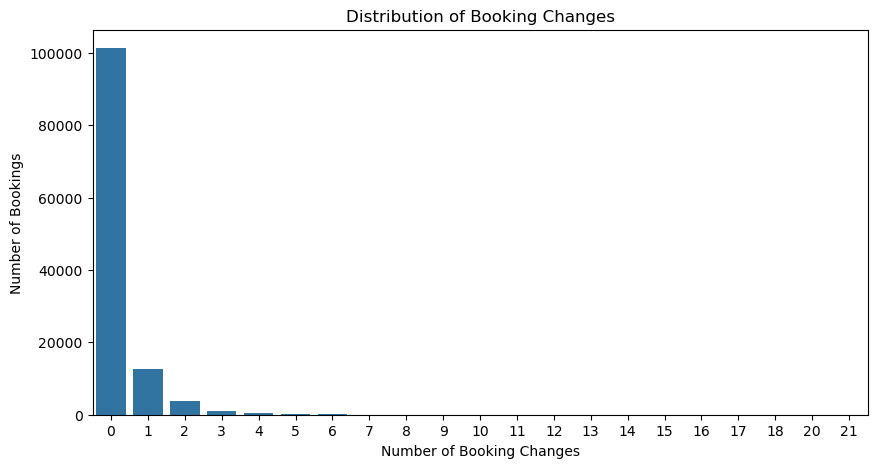

In [33]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x='booking_changes')

plt.title('Distribution of Booking Changes')
plt.xlabel('Number of Booking Changes')
plt.ylabel('Number of Bookings')
plt.show()

### Observations

- The booking_changes feature is highly concentrated at 0, indicating that most bookings were not modified after being made. Only a small proportion of bookings underwent one or more changes. The distribution is therefore highly right-skewed, with a few bookings having a relatively high number of changes.

In [34]:
df['agent'].head()

0      NaN
1      NaN
2      NaN
3    304.0
4    240.0
Name: agent, dtype: float64

In [35]:
df['agent'].nunique()

333

### Observations 

- The agent feature represents the ID of the travel/booking agent through which the reservation was made. Since these values are identifiers rather than meaningful numerical quantities, statistical measures such as mean, median, skewness, and numerical distribution are not directly meaningful. The feature contains multiple unique agent IDs and may be explored later based on booking frequency or its relationship with the cancellation status.

In [36]:
df['company'].describe()

count    6797.000000
mean      189.266735
std       131.655015
min         6.000000
25%        62.000000
50%       179.000000
75%       270.000000
max       543.000000
Name: company, dtype: float64

In [37]:
df['company'].value_counts(dropna=False).head(10)

company
NaN      112593
40.0        927
223.0       784
67.0        267
45.0        250
153.0       215
174.0       149
219.0       141
281.0       138
154.0       133
Name: count, dtype: int64

In [38]:
df['company'].nunique()

352

### Observations 

company contains identifier values rather than meaningful numerical measurements, so numerical concepts such as mean, skewness, and outliers are not directly meaningful. The boxplot does not flag any values as statistical outliers under the IQR rule, but this does not imply that the company IDs themselves have meaningful numerical distribution.

In [39]:
df['days_in_waiting_list'].head()

0    0
1    0
2    0
3    0
4    0
Name: days_in_waiting_list, dtype: int64

In [40]:
df['days_in_waiting_list'].nunique()

128

In [41]:
df['days_in_waiting_list'].value_counts().head(15)

days_in_waiting_list
0      115692
39        227
58        164
44        141
31        127
35         96
46         94
69         89
63         83
87         80
50         80
38         76
111        71
101        65
45         65
Name: count, dtype: int64

### Observations 

The days_in_waiting_list feature is highly concentrated at 0, indicating that most bookings were not placed on a waiting list. Only a small proportion of bookings spent one or more days on the waiting list, resulting in a highly right-skewed distribution.

In [42]:
df['adr'].head()

0     0.0
1     0.0
2    75.0
3    75.0
4    98.0
Name: adr, dtype: float64

In [43]:
df['adr'].describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

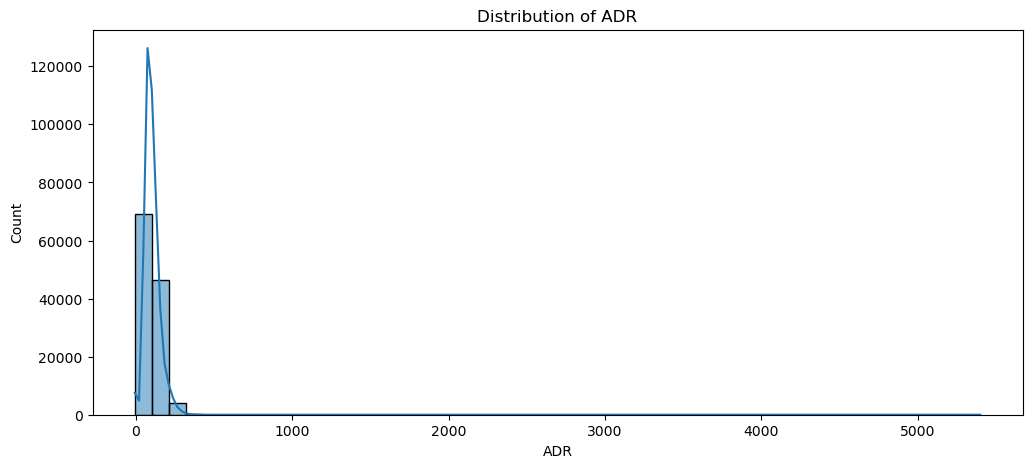

In [44]:
plt.figure(figsize=(12, 5))

sns.histplot(data=df, x='adr', bins=50, kde=True)

plt.title('Distribution of ADR')
plt.xlabel('ADR')
plt.ylabel('Count')

plt.show()

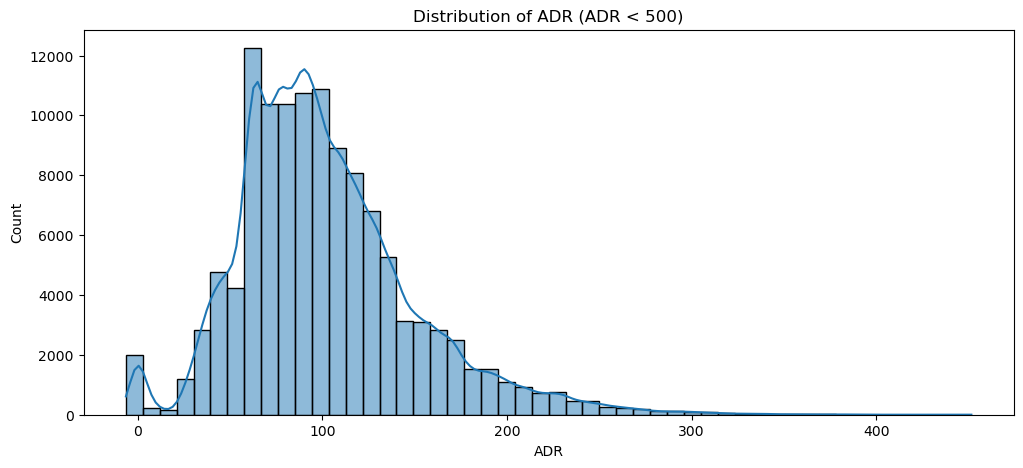

In [45]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df[df['adr'] < 500],
    x='adr',
    bins=50,
    kde=True
)

plt.title('Distribution of ADR (ADR < 500)')
plt.xlabel('ADR')
plt.ylabel('Count')

plt.show()

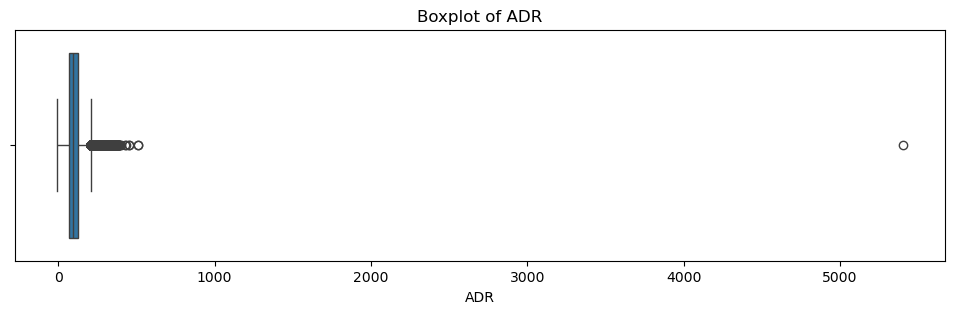

In [46]:
plt.figure(figsize=(12, 3))

sns.boxplot(data=df, x='adr')

plt.title('Boxplot of ADR')
plt.xlabel('ADR')

plt.show()

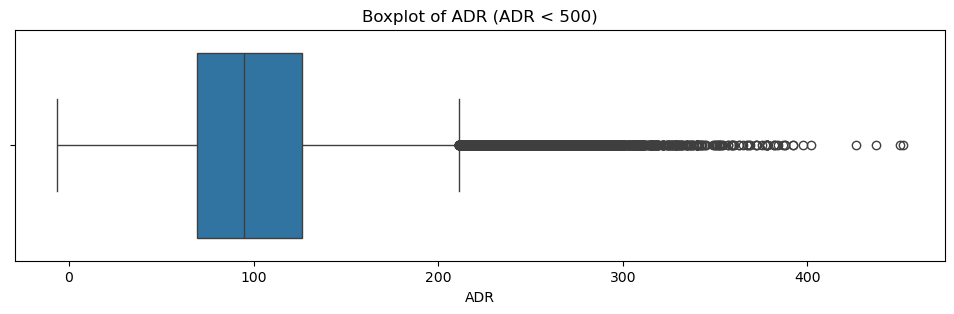

In [47]:
plt.figure(figsize=(12, 3))

sns.boxplot(data=df[df['adr'] < 500], x='adr')

plt.title('Boxplot of ADR (ADR < 500)')
plt.xlabel('ADR')

plt.show()

### Observations 

- The adr distribution is highly right-skewed. Most bookings have ADR values concentrated in a relatively lower range, while a smaller number of bookings have much higher ADR values, creating a long right tail. The boxplot also shows several high-value outliers, indicating substantial variation in room rates across bookings.
  
- The presence of extreme ADR values makes the original distribution appear highly compressed, so a zoomed-in visualization was used to better understand where the majority of observations are concentrated.

In [48]:
df['required_car_parking_spaces'].head()

0    0
1    0
2    0
3    0
4    0
Name: required_car_parking_spaces, dtype: int64

In [49]:
df['required_car_parking_spaces'].describe()

count    119390.000000
mean          0.062518
std           0.245291
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           8.000000
Name: required_car_parking_spaces, dtype: float64

### Observations

- required_car_parking_spaces is highly concentrated at 0, indicating that the vast majority of bookings did not require parking. Only a small proportion of bookings requested one or more parking spaces, resulting in a strongly right-skewed distribution. Although relatively uncommon, the feature may still be useful for analyzing its relationship with booking cancellations.

In [50]:
df['total_of_special_requests'].head()

0    0
1    0
2    0
3    0
4    1
Name: total_of_special_requests, dtype: int64

In [51]:
df['total_of_special_requests'].describe()

count    119390.000000
mean          0.571363
std           0.792798
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           5.000000
Name: total_of_special_requests, dtype: float64

### Observations 

- The total_of_special_requests feature is concentrated around 0, with a median of 0, indicating that most bookings have no special requests. The middle 50% of bookings have between 0 and 1 special request. The average number of special requests is approximately 0.57, while the maximum is 5, indicating that bookings with a large number of special requests are relatively uncommon


### Analysis of Categorical Features

In [52]:
df['hotel'].value_counts()

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

In [53]:
df['hotel'].value_counts()/len(df)*100

hotel
City Hotel      66.446101
Resort Hotel    33.553899
Name: count, dtype: float64

<Axes: xlabel='hotel', ylabel='count'>

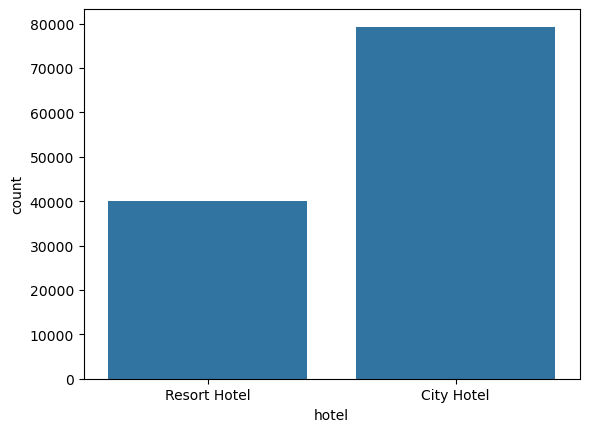

In [54]:
sns.countplot(data = df , x= df['hotel'])

### Observation

- There are two categories of hotel specified in dataset : Resort hotel and City hotel
- City Hotel accounts for the majority of bookings in the dataset approximatley 66.4 %, while Resort Hotel represents a smaller proportion of bookings nearly  33.3 %.

In [55]:
df['meal'].value_counts()

meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

In [56]:
df['meal'].value_counts(normalize = True)*100

meal
BB           77.318033
HB           12.114080
SC            8.920345
Undefined     0.979144
FB            0.668398
Name: proportion, dtype: float64

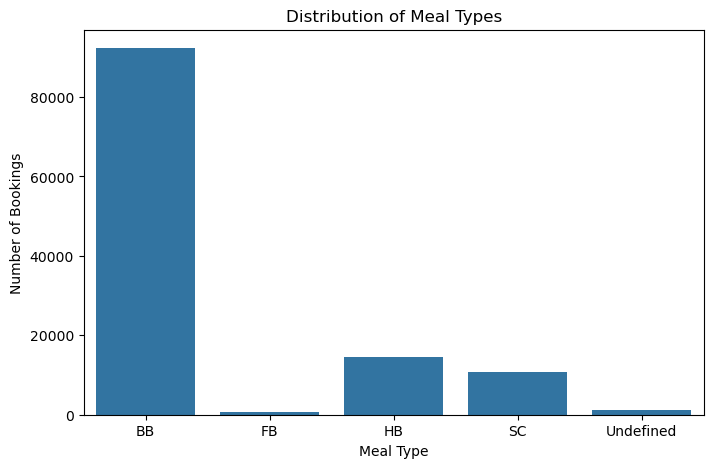

In [57]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='meal')

plt.title('Distribution of Meal Types')
plt.xlabel('Meal Type')
plt.ylabel('Number of Bookings')

plt.show()

### Onservations 

- There are five main categories in the meal column : 'BB' ,'FB' , 'HB' , 'SC' , 'undefined'
- The BB meal plan is the most common among bookings nearly 77.3 %, while other meal types occur less frequently. The SC, FB, and Undefined categories represent relatively smaller proportions of bookings.

In [58]:
df['market_segment'].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

In [59]:
df['market_segment'].value_counts(normalize=True) * 100

market_segment
Online TA        47.304632
Offline TA/TO    20.285619
Groups           16.593517
Direct           10.558673
Corporate         4.435045
Complementary     0.622330
Aviation          0.198509
Undefined         0.001675
Name: proportion, dtype: float64

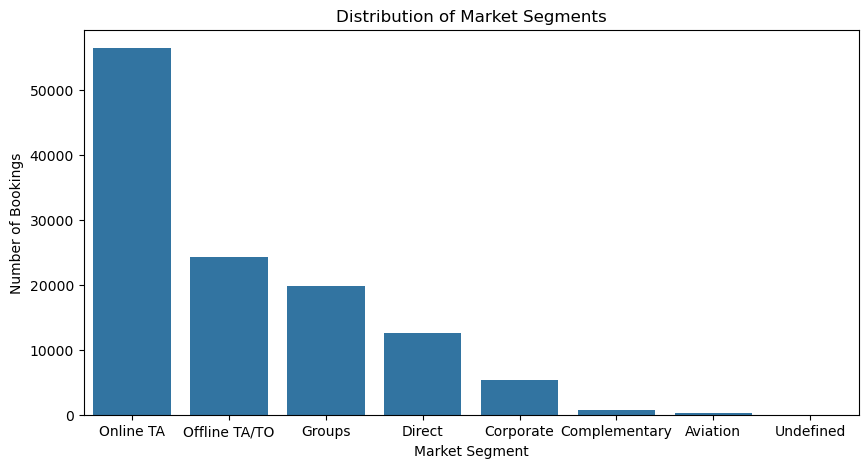

In [60]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='market_segment',
    order=df['market_segment'].value_counts().index
)

plt.xticks()
plt.title('Distribution of Market Segments')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')

plt.show()

### Observations 

- The market_segment feature is dominated by bookings from Online Travel Agents (Online TA), followed by Offline Travel Agents/Tour Operators. Direct, Groups, and Corporate bookings represent smaller proportions, while Complementary and Aviation bookings are relatively uncommon.

In [61]:
df['country'].value_counts()

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
       ...  
DJI        1
BWA        1
HND        1
VGB        1
NAM        1
Name: count, Length: 177, dtype: int64

In [62]:
df['country'].nunique()

177

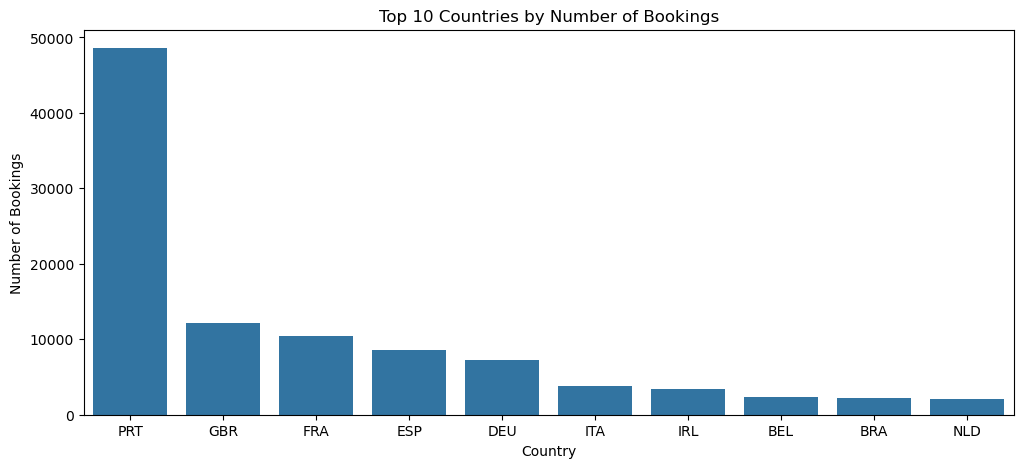

In [63]:
top_countries = df['country'].value_counts().head(10).index

plt.figure(figsize=(12,5))

sns.countplot(
    data=df[df['country'].isin(top_countries)],
    x='country',
    order=top_countries
)

plt.title('Top 10 Countries by Number of Bookings')
plt.xlabel('Country')
plt.ylabel('Number of Bookings')

plt.show()

### Observations 

- The country feature contains bookings from guests belonging to a large number of different countries. However, the bookings are highly concentrated among a few countries, with the most common country contributing a significantly larger number of bookings than the others. The remaining countries contribute comparatively fewer bookings.
- Guests from Portugal (PRT) account for the largest proportion of bookings, followed by a smaller number of bookings from other countries. Although the dataset contains guests from many countries, most bookings are concentrated among a relatively small group of countries.

In [64]:
df['distribution_channel'].value_counts()

distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

In [65]:
df['distribution_channel'].value_counts(normalize=True)*100

distribution_channel
TA/TO        81.975040
Direct       12.266521
Corporate     5.592596
GDS           0.161655
Undefined     0.004188
Name: proportion, dtype: float64

<Axes: xlabel='distribution_channel', ylabel='count'>

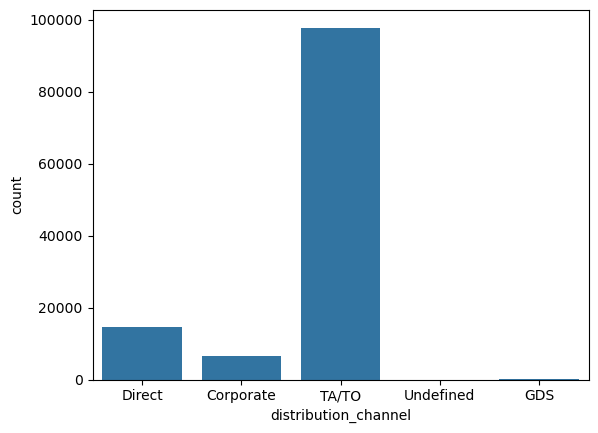

In [66]:
sns.countplot( data = df , x= df['distribution_channel'])

### Observations 

- The distribution_channel feature is highly concentrated in the TA/TO category, indicating that most bookings were received through travel agents or tour operators. Direct and Corporate channels account for a smaller proportion of bookings, while GDS and Undefined categories are relatively uncommon.

In [67]:
df['reserved_room_type'].value_counts()

reserved_room_type
A    85994
D    19201
E     6535
F     2897
G     2094
B     1118
C      932
H      601
P       12
L        6
Name: count, dtype: int64

In [68]:
df['reserved_room_type'].value_counts(normalize=True) * 100

reserved_room_type
A    72.027808
D    16.082586
E     5.473658
F     2.426501
G     1.753916
B     0.936427
C     0.780635
H     0.503392
P     0.010051
L     0.005026
Name: proportion, dtype: float64

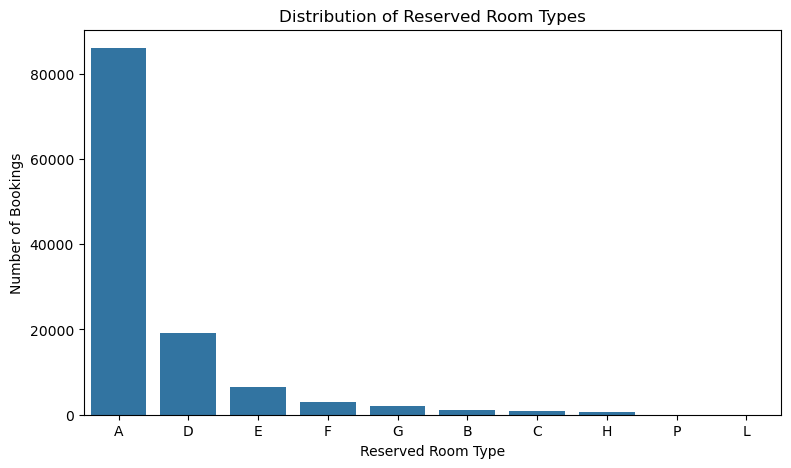

In [69]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='reserved_room_type',
    order=df['reserved_room_type'].value_counts().index
)

plt.title('Distribution of Reserved Room Types')
plt.xlabel('Reserved Room Type')
plt.ylabel('Number of Bookings')

plt.show()

### Observations 

 - The reserved_room_type feature is dominated by room type A, indicating that it is the most frequently requested room type. Other room types account for considerably fewer bookings, showing that the distribution of requested room types is highly concentrated.

In [70]:
df['assigned_room_type'].value_counts()

assigned_room_type
A    74053
D    25322
E     7806
F     3751
G     2553
C     2375
B     2163
H      712
I      363
K      279
P       12
L        1
Name: count, dtype: int64

In [71]:
df['assigned_room_type'].value_counts(normalize=True) * 100

assigned_room_type
A    62.026133
D    21.209482
E     6.538236
F     3.141804
G     2.138370
C     1.989279
B     1.811710
H     0.596365
I     0.304046
K     0.233688
P     0.010051
L     0.000838
Name: proportion, dtype: float64

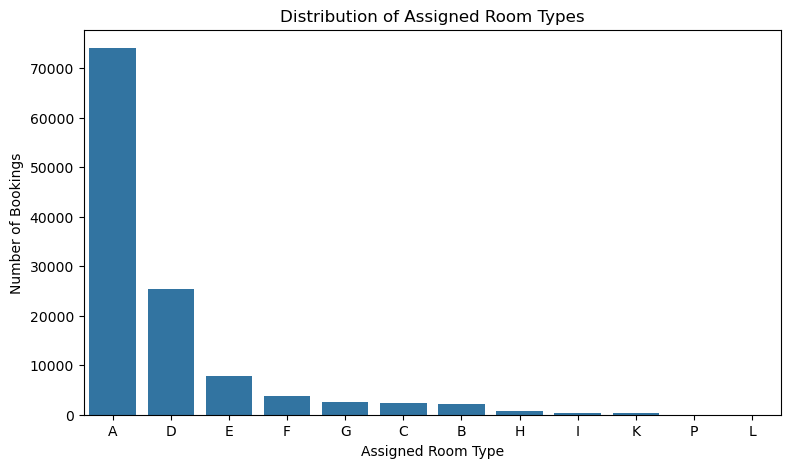

In [72]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='assigned_room_type',
    order=df['assigned_room_type'].value_counts().index
)

plt.title('Distribution of Assigned Room Types')
plt.xlabel('Assigned Room Type')
plt.ylabel('Number of Bookings')

plt.show()

### Observations

- The assigned_room_type feature is also highly concentrated in room type A, indicating that most bookings were ultimately assigned this room type. Other room types occur less frequently

In [73]:
df['deposit_type'].value_counts()

deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

In [74]:
df['deposit_type'].value_counts(normalize=True) * 100

deposit_type
No Deposit    87.646369
Non Refund    12.217941
Refundable     0.135690
Name: proportion, dtype: float64

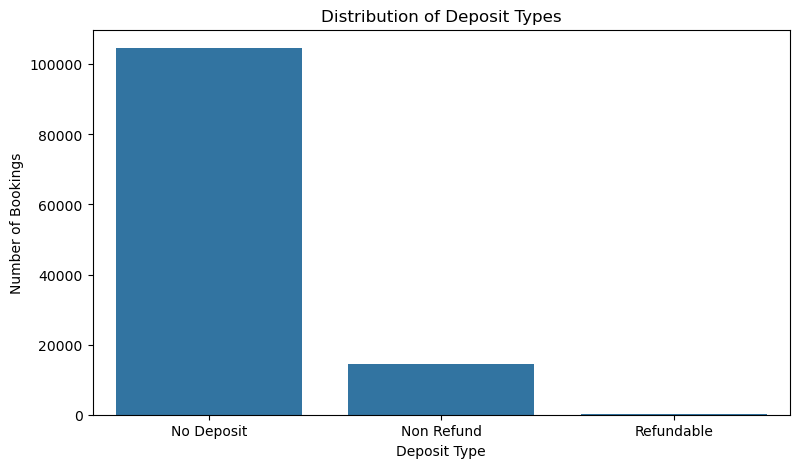

In [75]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='deposit_type',
    order=df['deposit_type'].value_counts().index
)

plt.title('Distribution of Deposit Types')
plt.xlabel('Deposit Type')
plt.ylabel('Number of Bookings')

plt.show()

### Observations 

- The deposit_type feature is highly imbalanced, with the vast majority of bookings belonging to the No Deposit category. Non Refund bookings represent a much smaller proportion, while Refundable bookings are very rare.

In [76]:
df['customer_type'].value_counts()

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

In [77]:
df['customer_type'].value_counts(normalize = True )

customer_type
Transient          0.750591
Transient-Party    0.210436
Contract           0.034140
Group              0.004833
Name: proportion, dtype: float64

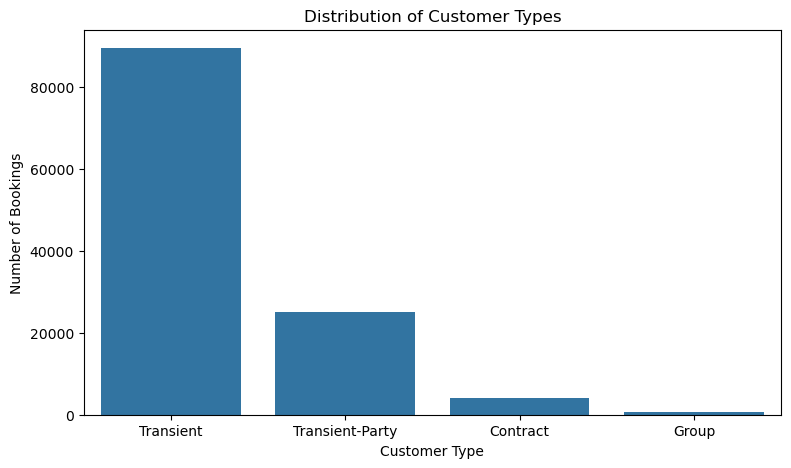

In [78]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='customer_type',
    order=df['customer_type'].value_counts().index
)


plt.title('Distribution of Customer Types')
plt.xlabel('Customer Type')
plt.ylabel('Number of Bookings')

plt.show()

### Observations 

- The customer_type feature is dominated by the Transient category, indicating that most bookings are individual/temporary reservations. Transient-Party, Contract, and Group bookings make up considerably smaller proportions of the dataset.

In [79]:
df['reservation_status'].value_counts()

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

In [80]:
df['reservation_status'].value_counts(normalize=True) * 100

reservation_status
Check-Out    62.958372
Canceled     36.030656
No-Show       1.010972
Name: proportion, dtype: float64

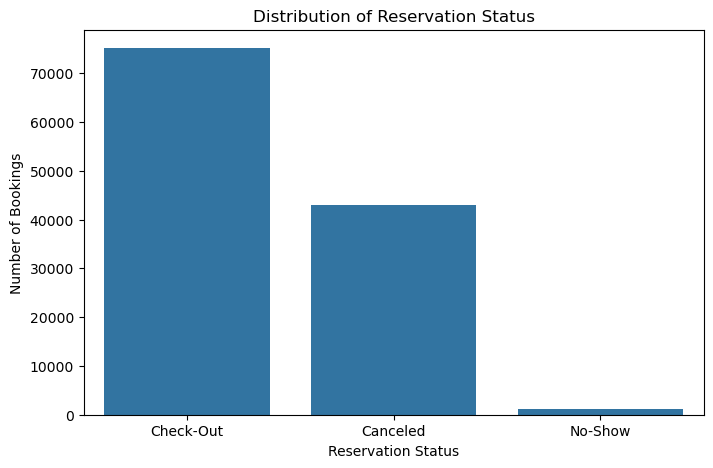

In [81]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='reservation_status',
    order=df['reservation_status'].value_counts().index
)

plt.title('Distribution of Reservation Status')
plt.xlabel('Reservation Status')
plt.ylabel('Number of Bookings')

plt.show()

### Observations

- The Check-Out category represents the largest proportion of reservations, followed by Canceled, while No-Show reservations are relatively uncommon  

In [82]:
df['arrival_date_month'].value_counts()

arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64

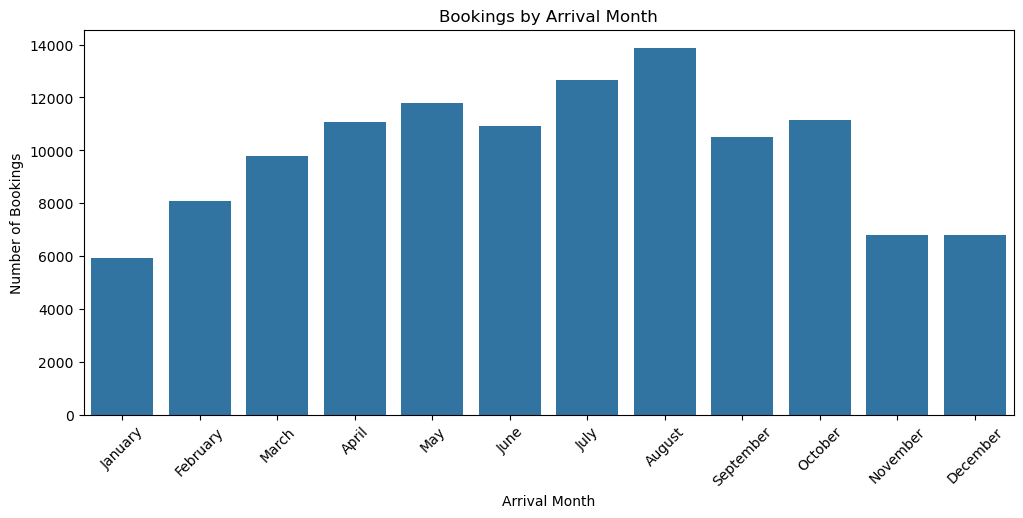

In [83]:
months = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='arrival_date_month',
    order=months
)

plt.title('Bookings by Arrival Month')
plt.xlabel('Arrival Month')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)
plt.show()

### Observations

The distribution of bookings varies across arrival months, indicating that hotel demand is not uniform throughout the year. Certain months have considerably higher booking volumes, while others have relatively fewer bookings, suggesting the presence of seasonality in hotel bookings.

In [84]:
df['reservation_status_date'] = pd.to_datetime(
    df['reservation_status_date']
)

In [85]:
df['reservation_status_date'].describe()

count                           119390
mean     2016-07-30 00:24:47.883407104
min                2014-10-17 00:00:00
25%                2016-02-01 00:00:00
50%                2016-08-07 00:00:00
75%                2017-02-08 00:00:00
max                2017-09-14 00:00:00
Name: reservation_status_date, dtype: object

### Observations 

- reservation_status_date is a date-based feature representing when the reservation status was recorded or last updated. Since it contains a large number of unique dates, treating it as a simple categorical variable is not appropriate. Its distribution is better explored as a time-based feature in a later analysis.

### BIVARIATE ANALYSIS WITH TARGET COLUMN 

### Numerical Features vs target feature 

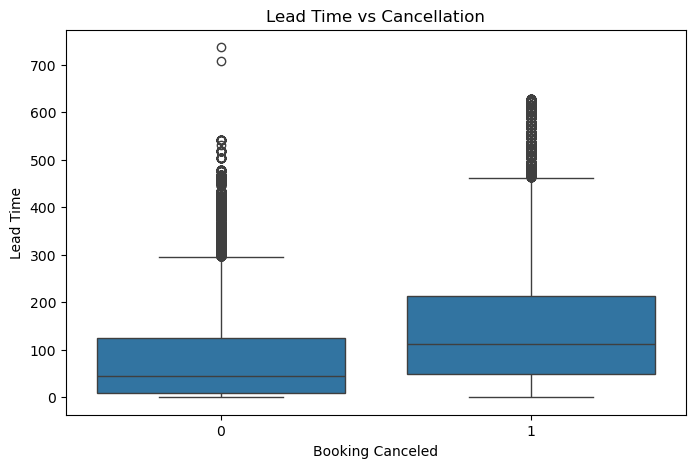

In [86]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_canceled',
    y='lead_time'
)

plt.title('Lead Time vs Cancellation')
plt.xlabel('Booking Canceled')
plt.ylabel('Lead Time')

plt.show()

### Observations 

- Canceled bookings generally have higher lead times than non-canceled bookings. The median lead time for canceled bookings is considerably higher, indicating that bookings made further in advance tend to have a higher likelihood of cancellation. The canceled group also shows a wider spread in lead time.

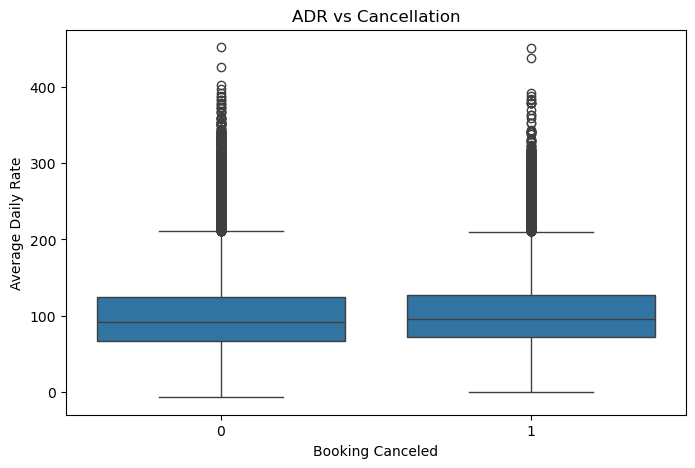

In [87]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df[df['adr']<500],
    x='is_canceled',
    y='adr'
)

plt.title('ADR vs Cancellation')
plt.xlabel('Booking Canceled')
plt.ylabel('Average Daily Rate')

plt.show()

### Observations

- The ADR distributions for canceled and non-canceled bookings are quite similar. The median ADR for canceled bookings is slightly higher than for non-canceled bookings, but the difference is relatively small. Both groups contain several high-value outliers, indicating the presence of unusually expensive bookings.

In [88]:
df.groupby('is_canceled')['adr'].agg(['count', 'mean', 'median'])

,count,mean,median
is_canceled,,,
0,75166,99.987693,92.5
1,44224,104.964333,96.2


### Observations 

- The average daily rate is slightly higher for canceled bookings than for non-canceled bookings. The mean ADR is approximately 105 for canceled bookings compared with 100 for non-canceled bookings, while the median ADR is 96.2 and 92.5 respectively. The relatively small difference suggests that ADR has a weaker association with cancellation compared with features such as lead time. Both groups also show right-skewness and several high ADR outliers.

In [89]:
df.groupby('is_canceled')['stays_in_weekend_nights'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
is_canceled,,,
0,75166,0.928971,1.0
1,44224,0.925267,1.0


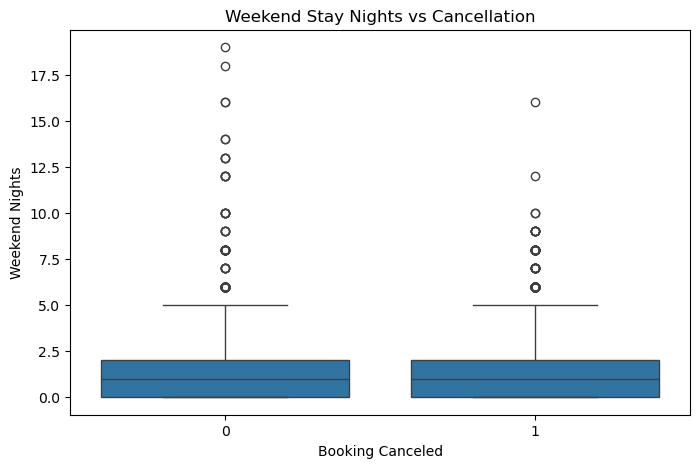

In [90]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_canceled',
    y='stays_in_weekend_nights'
)

plt.title('Weekend Stay Nights vs Cancellation')
plt.xlabel('Booking Canceled')
plt.ylabel('Weekend Nights')

plt.show()

### Observations 

- The number of weekend nights is very similar for canceled and non-canceled bookings. The mean is approximately 0.93 for non-canceled bookings and 0.93 for canceled bookings, while the median is 1 for both groups. This suggests that stays_in_weekend_nights has little apparent association with booking cancellation.

In [91]:
df.groupby('is_canceled')['stays_in_week_nights'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
is_canceled,,,
0,75166,2.464053,2.0
1,44224,2.561912,2.0


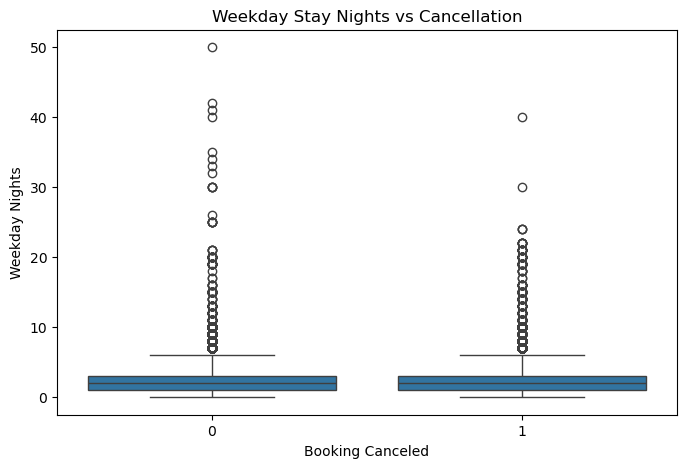

In [92]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_canceled',
    y='stays_in_week_nights'
)

plt.title('Weekday Stay Nights vs Cancellation')
plt.xlabel('Booking Canceled')
plt.ylabel('Weekday Nights')

plt.show()

### Observations 

- The number of weekday nights is broadly similar for canceled and non-canceled bookings. Both groups have a median of 2 nights, while the mean is only slightly higher for canceled bookings (2.56 vs 2.46). This suggests that stays_in_week_nights has a relatively weak apparent association with cancellation.

In [93]:
df.groupby('is_canceled')['previous_cancellations'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
is_canceled,,,
0,75166,0.015792,0.0
1,44224,0.208348,0.0


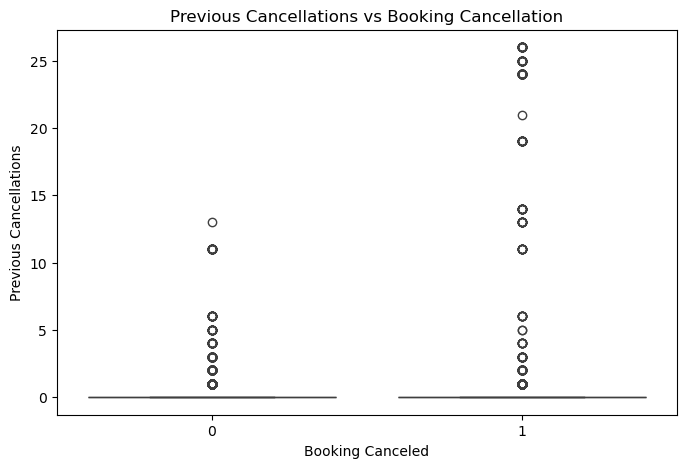

In [94]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_canceled',
    y='previous_cancellations'
)

plt.title('Previous Cancellations vs Booking Cancellation')
plt.xlabel('Booking Canceled')
plt.ylabel('Previous Cancellations')

plt.show()

In [95]:
pd.crosstab(
    df['previous_cancellations'] > 0,
    df['is_canceled'],
    normalize='columns'
) * 100

is_canceled,0,1
previous_cancellations,,
False,99.278929,86.563857
True,0.721071,13.436143


### Observations

- Previous cancellations are highly concentrated at zero, with the median being 0 for both canceled and non-canceled bookings. However, the percentage analysis reveals a substantial difference: only 0.72% of non-canceled bookings had at least one previous cancellation, compared with 13.44% of canceled bookings. This indicates a strong association between a guest's previous cancellation history and the cancellation of their current booking.

In [96]:
df.groupby('is_canceled')['previous_bookings_not_canceled'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
is_canceled,,,
0,75166,0.202977,0.0
1,44224,0.025122,0.0


In [97]:
df.groupby('is_canceled')['previous_bookings_not_canceled'].apply(
    lambda x: (x > 0).mean() * 100
)

is_canceled
0    4.549929
1    0.452243
Name: previous_bookings_not_canceled, dtype: float64

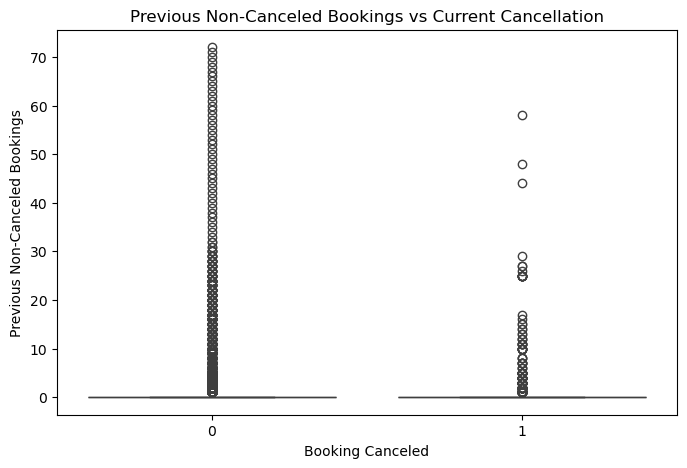

In [98]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_canceled',
    y='previous_bookings_not_canceled'
)

plt.title('Previous Non-Canceled Bookings vs Current Cancellation')
plt.xlabel('Booking Canceled')
plt.ylabel('Previous Non-Canceled Bookings')

plt.show()

### Observations

- previous_bookings_not_canceled is highly concentrated at zero, with a median of 0 for both groups. However, the mean is considerably higher for non-canceled bookings (0.203) than for canceled bookings (0.025). Additionally, 4.55% of non-canceled bookings had at least one previous successfully completed booking, compared with only 0.45% of canceled bookings. This suggests that a history of successfully completed bookings is negatively associated with cancellation of the current booking.

In [99]:
df.groupby('is_canceled')['booking_changes'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
is_canceled,,,
0,75166,0.293364,0.0
1,44224,0.098340,0.0


In [100]:
df.groupby('is_canceled')['booking_changes'].apply(
    lambda x: (x > 0).mean() * 100
)

is_canceled
0    20.279116
1     6.406024
Name: booking_changes, dtype: float64

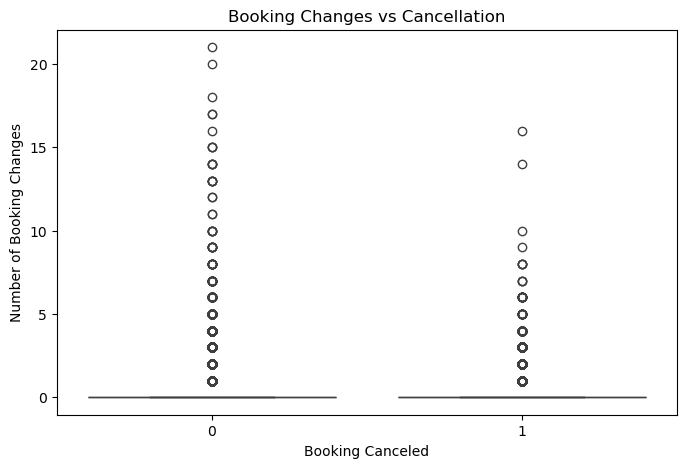

In [101]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_canceled',
    y='booking_changes'
)

plt.title('Booking Changes vs Cancellation')
plt.xlabel('Booking Canceled')
plt.ylabel('Number of Booking Changes')

plt.show()

### Observations

- booking_changes is highly concentrated at zero, with a median of 0 for both canceled and non-canceled bookings. However, the mean number of changes is higher for non-canceled bookings (0.293) than for canceled bookings (0.098). Additionally, 20.28% of non-canceled bookings had at least one change compared with only 6.41% of canceled bookings. This suggests that booking changes are negatively associated with cancellation.

In [102]:
df['agent'].value_counts().head(10)

agent
9.0      31961
240.0    13922
1.0       7191
14.0      3640
7.0       3539
6.0       3290
250.0     2870
241.0     1721
28.0      1666
8.0       1514
Name: count, dtype: int64

In [103]:
top_agents = df['agent'].value_counts().head(10).index

agent_cancellation = (
    df[df['agent'].isin(top_agents)]
    .groupby('agent')['is_canceled']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

agent_cancellation

agent
1.0      73.425115
9.0      41.500579
240.0    39.390892
6.0      31.155015
8.0      28.203435
14.0     17.912088
250.0    17.874564
241.0    13.712958
7.0      13.393614
28.0      6.602641
Name: is_canceled, dtype: float64

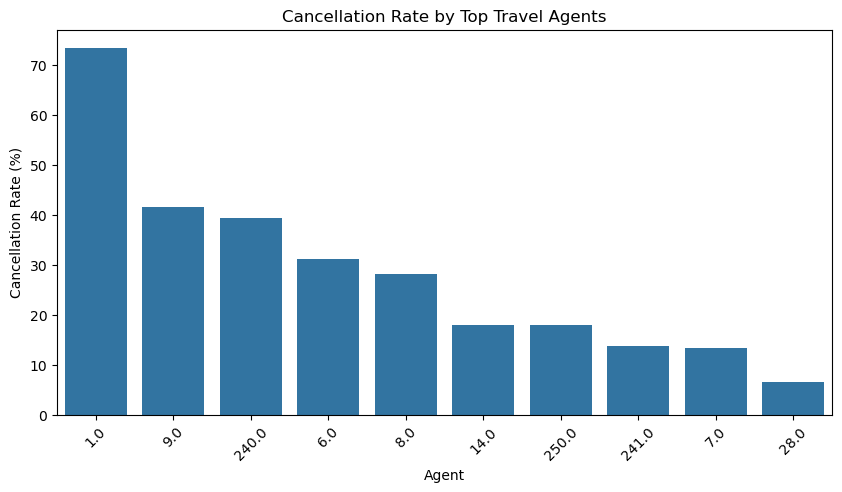

In [104]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=agent_cancellation.index.astype(str),
    y=agent_cancellation.values
)

plt.title('Cancellation Rate by Top Travel Agents')
plt.xlabel('Agent')
plt.ylabel('Cancellation Rate (%)')

plt.xticks(rotation=45)

plt.show()

In [105]:
agent_stats = (
    df[df['agent'].isin(top_agents)]
    .groupby('agent')['is_canceled']
    .agg(['count', 'mean'])
)

agent_stats['cancellation_rate'] = agent_stats['mean'] * 100

agent_stats.sort_values('cancellation_rate', ascending=False)

,count,mean,cancellation_rate
agent,,,
1.0,7191,0.734251,73.425115
9.0,31961,0.415006,41.500579
240.0,13922,0.393909,39.390892
6.0,3290,0.311550,31.155015
8.0,1514,0.282034,28.203435
14.0,3640,0.179121,17.912088
250.0,2870,0.178746,17.874564
241.0,1721,0.137130,13.712958
7.0,3539,0.133936,13.393614


### Observations 

- The cancellation rate varies considerably across the top 10 most frequently used travel agents. Agent 1 has the highest cancellation rate at approximately 73.4%, while Agent 28 has the lowest at approximately 6.6%. This indicates a strong variation in cancellation behavior across agents, although the analysis shows association rather than causation.

In [106]:
df['company'].value_counts().head(10)

company
40.0     927
223.0    784
67.0     267
45.0     250
153.0    215
174.0    149
219.0    141
281.0    138
154.0    133
405.0    119
Name: count, dtype: int64

In [107]:
top_companies = df['company'].value_counts().head(10).index

company_stats = (
    df[df['company'].isin(top_companies)]
    .groupby('company')['is_canceled']
    .agg(['count', 'mean'])
)

company_stats['cancellation_rate'] = company_stats['mean'] * 100

company_stats.sort_values('cancellation_rate', ascending=False)

,count,mean,cancellation_rate
company,,,
67.0,267,0.655431,65.543071
153.0,215,0.223256,22.325581
223.0,784,0.151786,15.178571
405.0,119,0.151261,15.126050
174.0,149,0.140940,14.093960
281.0,138,0.123188,12.318841
45.0,250,0.112000,11.200000
40.0,927,0.083064,8.306365
219.0,141,0.063830,6.382979


### Observations 

- Cancellation rates vary considerably among the top 10 companies by booking frequency. Company 67 has the highest cancellation rate at approximately 65.5%, while Company 154 has the lowest at approximately 3.8%. However, some companies have relatively small numbers of bookings, so their cancellation rates should be interpreted cautiously. Overall, the feature shows an association between company and cancellation behavior.

In [108]:
df.groupby('is_canceled')['days_in_waiting_list'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
is_canceled,,,
0,75166,1.589868,0.0
1,44224,3.564083,0.0


In [109]:
df.groupby('is_canceled')['days_in_waiting_list'].apply(
    lambda x: (x > 0).mean() * 100
)

is_canceled
0    1.781391
1    5.334208
Name: days_in_waiting_list, dtype: float64

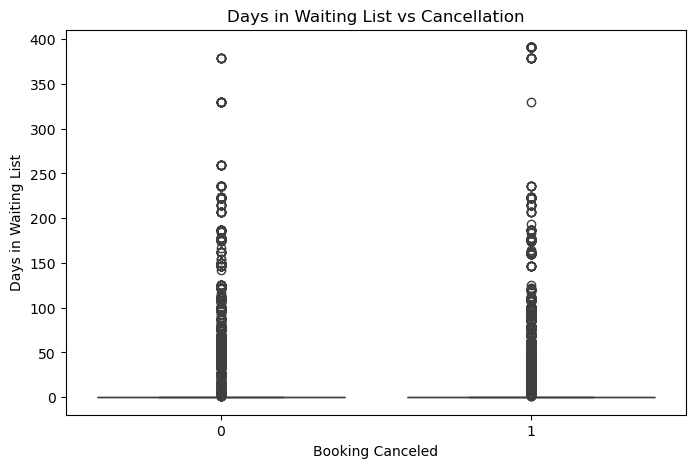

In [110]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_canceled',
    y='days_in_waiting_list'
)

plt.title('Days in Waiting List vs Cancellation')
plt.xlabel('Booking Canceled')
plt.ylabel('Days in Waiting List')

plt.show()

### Observations

- days_in_waiting_list is highly concentrated at zero, with a median of 0 for both canceled and non-canceled bookings. However, canceled bookings have a higher mean waiting time (3.56 days) compared with non-canceled bookings (1.59 days). Additionally, 5.33% of canceled bookings had spent at least one day on the waiting list, compared with 1.78% of non-canceled bookings. This suggests that longer waiting-list periods are associated with a higher likelihood of cancellation.

In [111]:
df.groupby('is_canceled')['required_car_parking_spaces'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
is_canceled,,,
0,75166,0.0993,0.0
1,44224,0.0000,0.0


In [112]:
df.groupby('is_canceled')['required_car_parking_spaces'].apply(
    lambda x: (x > 0).mean() * 100
)

is_canceled
0    9.866163
1    0.000000
Name: required_car_parking_spaces, dtype: float64

### Observations 

- required_car_parking_spaces is highly concentrated at zero, with a median of 0 for both groups. The mean is higher for non-canceled bookings (0.0993) compared with canceled bookings (0). Additionally, 9.87% of non-canceled bookings requested at least one parking space, whereas none of the canceled bookings did. This indicates a strong association between requesting parking space and non-cancellation in this dataset.

In [113]:
df.groupby('is_canceled')['total_of_special_requests'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
is_canceled,,,
0,75166,0.714060,1.0
1,44224,0.328826,0.0


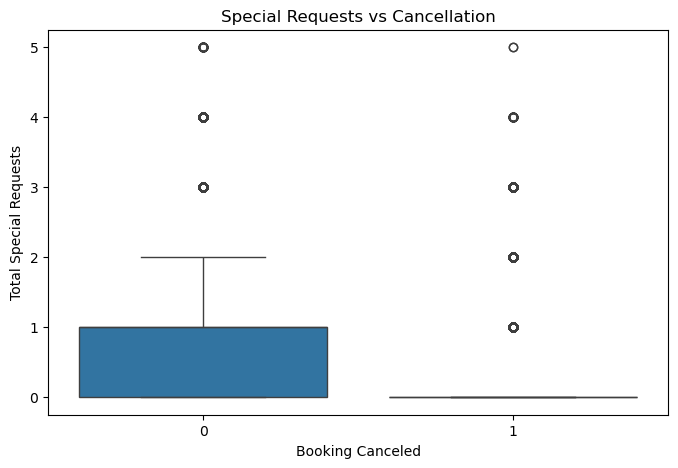

In [114]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_canceled',
    y='total_of_special_requests'
)

plt.title('Special Requests vs Cancellation')
plt.xlabel('Booking Canceled')
plt.ylabel('Total Special Requests')

plt.show()

### Observations 

- total_of_special_requests differs between canceled and non-canceled bookings. The non-canceled group has a higher mean (0.714) and median (1) compared with the canceled group (mean = 0.329, median = 0). This indicates that bookings with more special requests are more commonly associated with non-canceled bookings.

### Observations

### Analysis of Categorical  vs Target Features 

In [115]:
cat_col

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type',
 'reservation_status',
 'reservation_status_date']

In [116]:
pd.crosstab(
    df['hotel'],
    df['is_canceled'],
    normalize='index'
) * 100

is_canceled,0,1
hotel,,
City Hotel,58.273037,41.726963
Resort Hotel,72.236645,27.763355


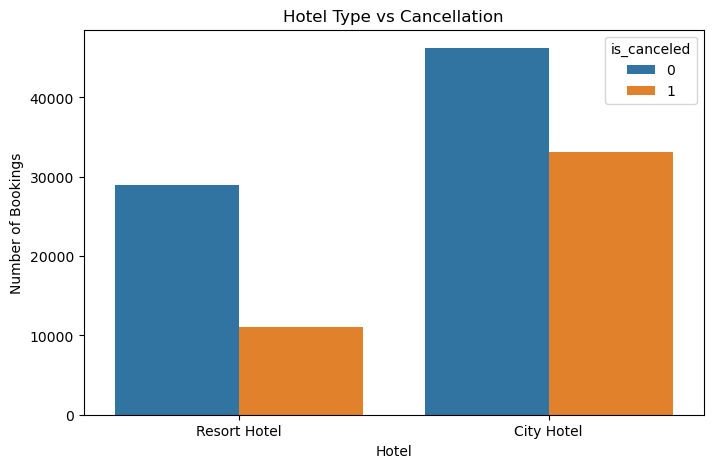

In [117]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='hotel',
    hue='is_canceled'
)

plt.title('Hotel Type vs Cancellation')
plt.xlabel('Hotel')
plt.ylabel('Number of Bookings')

plt.show()

### Observations 

 - The cancellation rate is higher for City Hotel bookings than for Resort Hotel bookings. Approximately 41.7% of City Hotel bookings were canceled, compared with around 27.8% of Resort Hotel bookings. This indicates that hotel type is associated with booking cancellation, with City Hotel showing a higher cancellation rate.

In [118]:
df['meal'].value_counts()

meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

In [119]:
pd.crosstab(
    df['meal'],
    df['is_canceled'],
    normalize= 'index'
)*100

is_canceled,0,1
meal,,
BB,62.615101,37.384899
FB,40.100251,59.899749
HB,65.539653,34.460347
SC,62.760563,37.239437
Undefined,75.534645,24.465355


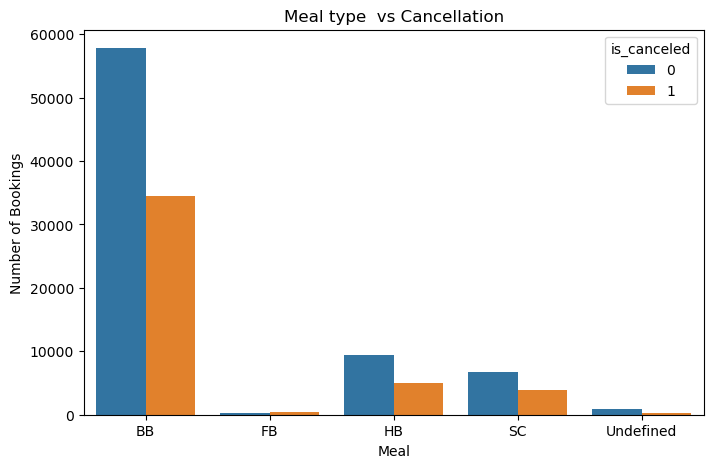

In [120]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='meal',
    hue='is_canceled'
)

plt.title('Meal type  vs Cancellation')
plt.xlabel('Meal')
plt.ylabel('Number of Bookings')

plt.show()

### Observations 

- Cancellation rates vary across meal types. Full Board (FB) has the highest cancellation rate at approximately 59.9%, while Undefined has the lowest at approximately 24.5%. BB, HB and SC show relatively similar cancellation rates, ranging from approximately 34% to 37%. However, the FB category has a relatively small number of bookings, so its high cancellation rate should be interpreted cautiously.

In [121]:
df['country'].value_counts().head(10)

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64

In [122]:
top_countries = df['country'].value_counts().head(10).index

country_stats = (
    df[df['country'].isin(top_countries)]
    .groupby('country')['is_canceled']
    .agg(['count', 'mean'])
)

country_stats['cancellation_rate'] = country_stats['mean'] * 100

country_stats.sort_values(
    'cancellation_rate',
    ascending=False
)

,count,mean,cancellation_rate
country,,,
PRT,48590,0.566351,56.635110
BRA,2224,0.373201,37.320144
ITA,3766,0.353956,35.395645
ESP,8568,0.254085,25.408497
IRL,3375,0.246519,24.651852
BEL,2342,0.202391,20.239112
GBR,12129,0.202243,20.224256
FRA,10415,0.185694,18.569371
NLD,2104,0.183935,18.393536


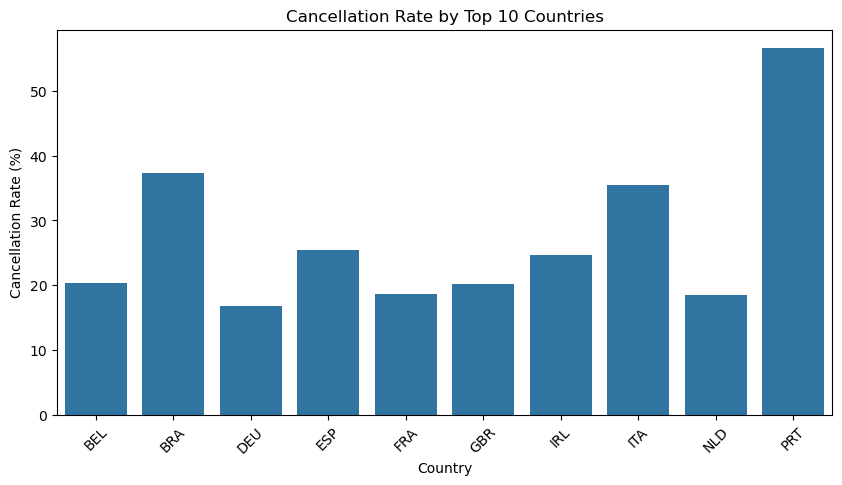

In [123]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=country_stats.reset_index(),
    x='country',
    y='cancellation_rate'
)

plt.title('Cancellation Rate by Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Cancellation Rate (%)')

plt.xticks(rotation=45)

plt.show()

### Observations

- Cancellation rates vary considerably among the top 10 countries by booking frequency. Portugal (PRT) has the highest cancellation rate at approximately 56.6%, followed by Brazil (37.3%) and Italy (35.4%). Germany (DEU) has the lowest cancellation rate among these countries at approximately 16.7%. This indicates a notable association between guest country and booking cancellation behavior.

In [124]:
df['market_segment'].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

In [125]:
pd.crosstab(
    df['market_segment'],
    df['is_canceled'],
    normalize='index'
) * 100

is_canceled,0,1
market_segment,,
Aviation,78.059072,21.940928
Complementary,86.944818,13.055182
Corporate,81.265345,18.734655
Direct,84.658099,15.341901
Groups,38.937964,61.062036
Offline TA/TO,65.683967,34.316033
Online TA,63.278857,36.721143
Undefined,0.000000,100.000000


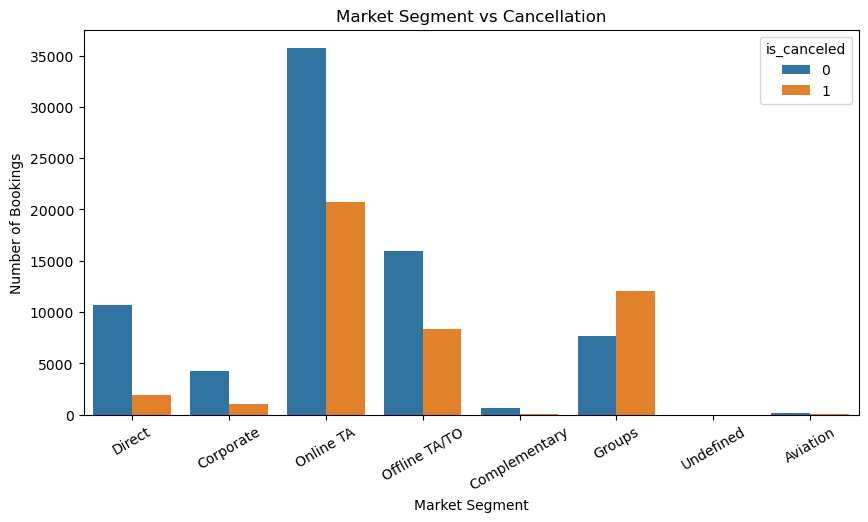

In [126]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='market_segment',
    hue='is_canceled'
)

plt.title('Market Segment vs Cancellation')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=30)

plt.show()

### Observations 

- Cancellation rates vary considerably across market segments. Groups has the highest cancellation rate among the meaningful categories at approximately 61.1%, followed by Online TA (36.7%) and Offline TA/TO (34.3%). Complementary has the lowest cancellation rate at approximately 13.1%. This indicates that booking cancellation behavior differs substantially across market segments.

In [127]:
df['distribution_channel'].value_counts()

distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

In [128]:
pd.crosstab(
    df['distribution_channel'],
    df['is_canceled'],
    normalize='index'
) * 100

is_canceled,0,1
distribution_channel,,
Corporate,77.924217,22.075783
Direct,82.540116,17.459884
GDS,80.829016,19.170984
TA/TO,58.974149,41.025851
Undefined,20.000000,80.000000


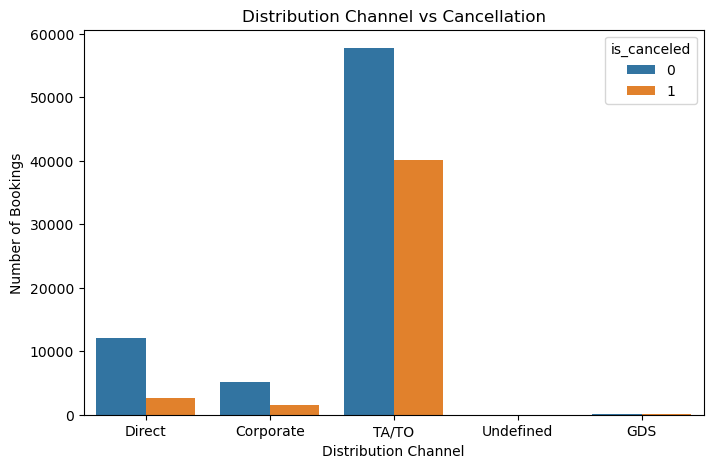

In [129]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='distribution_channel',
    hue='is_canceled'
)

plt.title('Distribution Channel vs Cancellation')
plt.xlabel('Distribution Channel')
plt.ylabel('Number of Bookings')

plt.show()

### Observations 

- Cancellation rates vary across distribution channels. TA/TO has the highest cancellation rate among the main distribution channels at approximately 41.0%, while Direct has the lowest at approximately 17.5%. Corporate and GDS channels show relatively lower cancellation rates of around 22% and 19%, respectively. This suggests an association between distribution channel and booking cancellation behavior.

In [130]:
df['reserved_room_type'].value_counts()

reserved_room_type
A    85994
D    19201
E     6535
F     2897
G     2094
B     1118
C      932
H      601
P       12
L        6
Name: count, dtype: int64

In [131]:
pd.crosstab(
    df['reserved_room_type'],
    df['is_canceled'],
    normalize='index'
) * 100

is_canceled,0,1
reserved_room_type,,
A,60.892620,39.107380
B,67.084079,32.915921
C,66.952790,33.047210
D,68.220405,31.779595
E,70.711553,29.288447
F,69.623749,30.376251
G,63.562560,36.437440
H,59.234609,40.765391
L,66.666667,33.333333


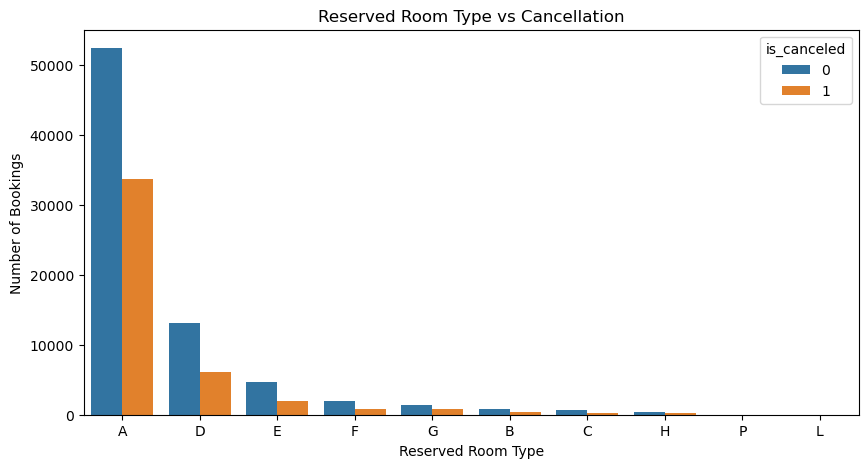

In [132]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='reserved_room_type',
    hue='is_canceled',
    order=df['reserved_room_type'].value_counts().index
)

plt.title('Reserved Room Type vs Cancellation')
plt.xlabel('Reserved Room Type')
plt.ylabel('Number of Bookings')

plt.show()

### Observations

- Cancellation rates vary across the reserved room types. Room H has the highest cancellation rate among the commonly occurring room types at approximately 40.8%, followed by Room A at 39.1%. Room E has the lowest cancellation rate at approximately 29.3%. Overall, most room types show cancellation rates between approximately 29% and 41%, indicating moderate variation in cancellation behavior across reserved room types.

In [133]:
df['assigned_room_type'].value_counts()

assigned_room_type
A    74053
D    25322
E     7806
F     3751
G     2553
C     2375
B     2163
H      712
I      363
K      279
P       12
L        1
Name: count, dtype: int64

In [134]:
pd.crosstab(
    df['assigned_room_type'],
    df['is_canceled'],
    normalize='index'
) * 100

is_canceled,0,1
assigned_room_type,,
A,55.507542,44.492458
B,76.329172,23.670828
C,81.221053,18.778947
D,74.875602,25.124398
E,74.788624,25.211376
F,75.286590,24.713410
G,69.447709,30.552291
H,64.747191,35.252809
I,98.622590,1.377410


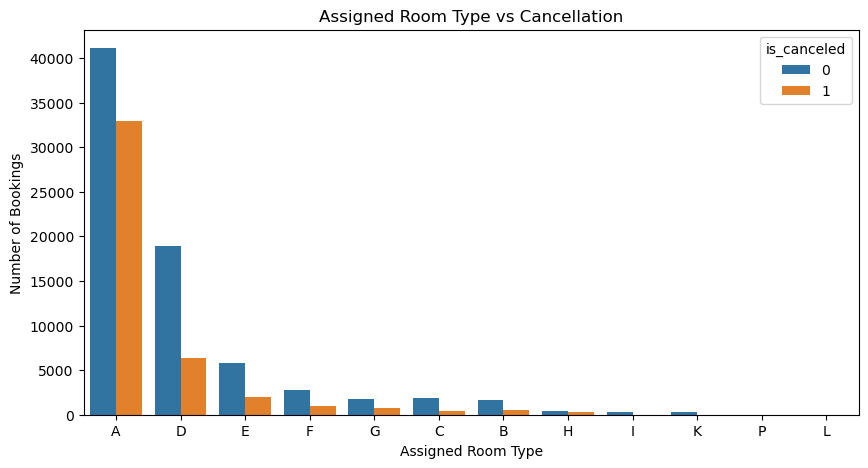

In [135]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='assigned_room_type',
    hue='is_canceled',
    order=df['assigned_room_type'].value_counts().index
)

plt.title('Assigned Room Type vs Cancellation')
plt.xlabel('Assigned Room Type')
plt.ylabel('Number of Bookings')

plt.show()

### Observations 

- Cancellation rates vary across the assigned room types. Room A has the highest cancellation rate among the commonly occurring room types at approximately 44.5%, followed by Room H at 35.3% and Room G at 30.6%. Room C has the lowest cancellation rate among the commonly occurring room types at approximately 18.8%. Overall, most room types show cancellation rates between approximately 19% and 45%, indicating noticeable variation in cancellation behavior across assigned room types.

In [136]:
df['deposit_type'].value_counts()

deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

In [137]:
pd.crosstab(
    df['deposit_type'],
    df['is_canceled'],
    normalize='index'
) * 100

is_canceled,0,1
deposit_type,,
No Deposit,71.622978,28.377022
Non Refund,0.637554,99.362446
Refundable,77.777778,22.222222


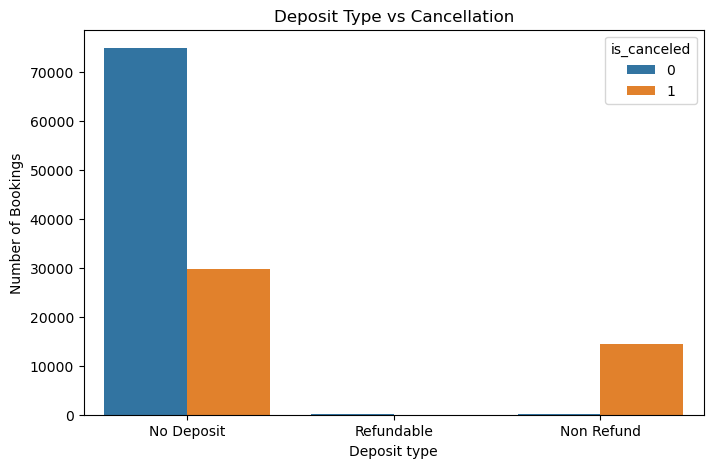

In [138]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='deposit_type',
    hue='is_canceled'
)

plt.title('Deposit Type vs Cancellation')
plt.xlabel('Deposit type')
plt.ylabel('Number of Bookings')

plt.show()

### Observations

- Cancellation rates vary significantly across deposit types. Non Refund bookings have an extremely high cancellation rate of approximately 99.4%, while No Deposit bookings have a much lower cancellation rate of approximately 28.4%. Refundable bookings have the lowest cancellation rate at approximately 22.2%. Overall, the deposit type shows a strong relationship with booking cancellation, with non-refundable bookings being overwhelmingly associated with cancellations.

In [140]:
df['customer_type'].value_counts()

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

In [141]:
pd.crosstab(
    df['customer_type'],
    df['is_canceled'],
    normalize='index'
) * 100

is_canceled,0,1
customer_type,,
Contract,69.038273,30.961727
Group,89.774697,10.225303
Transient,59.253680,40.746320
Transient-Party,74.570132,25.429868


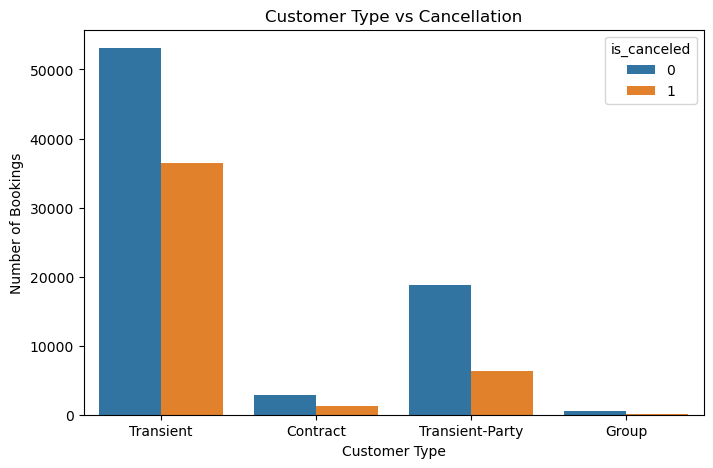

In [142]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='customer_type',
    hue='is_canceled'
)

plt.title('Customer Type vs Cancellation')
plt.xlabel('Customer Type')
plt.ylabel('Number of Bookings')

plt.show()

### Observations 

- Cancellation rates vary across customer types. Transient customers have the highest cancellation rate at approximately 40.75%, while Group customers have the lowest at approximately 10.23%. Contract and Transient-Party customers show intermediate cancellation rates of approximately 30.96% and 25.43%, respectively. This indicates an association between customer type and booking cancellation behavior.

In [143]:
df['reservation_status'].value_counts()

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

In [144]:
pd.crosstab(
    df['reservation_status'],
    df['is_canceled'],
    normalize='index'
) * 100

is_canceled,0,1
reservation_status,,
Canceled,0.0,100.0
Check-Out,100.0,0.0
No-Show,0.0,100.0


### Observations 

- reservation_status has a direct relationship with is_canceled. Canceled and no-show reservations correspond to canceled bookings, whereas check-out reservations correspond to non-canceled bookings. Since this feature represents the final reservation outcome, it would cause target leakage if used as an input feature for predicting cancellation.

In [145]:
df['reservation_status_date'] = pd.to_datetime(
    df['reservation_status_date']
)

In [146]:
df['reservation_status_date'].min(), df['reservation_status_date'].max()

(Timestamp('2014-10-17 00:00:00'), Timestamp('2017-09-14 00:00:00'))

In [147]:
df['status_year'] = df['reservation_status_date'].dt.year

In [148]:
pd.crosstab(
    df['status_year'],
    df['is_canceled'],
    normalize='index'
) * 100

is_canceled,0,1
status_year,,
2014,0.000000,100.000000
2015,54.001364,45.998636
2016,62.925411,37.074589
2017,69.443302,30.556698


### Observations 

- reservation_status_date represents the date on which the reservation status was recorded/updated. Its relationship with is_canceled should be interpreted cautiously because the date is associated with the final reservation outcome and may contain information that would not be available at the time of making a cancellation prediction. Therefore, it is not considered a suitable predictive feature without careful temporal treatment.

In [149]:
df['arrival_date_month'].value_counts()

arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64

In [155]:
pd.crosstab(
    df['arrival_date_month'],
    df['is_canceled'],
    normalize='index'
).reindex(months) * 100

is_canceled,0,1
arrival_date_month,,
January,69.522685,30.477315
February,66.584036,33.415964
March,67.847662,32.152338
April,59.202814,40.797186
May,60.334153,39.665847
June,58.542828,41.457172
July,62.546402,37.453598
August,62.246883,37.753117
September,60.829844,39.170156


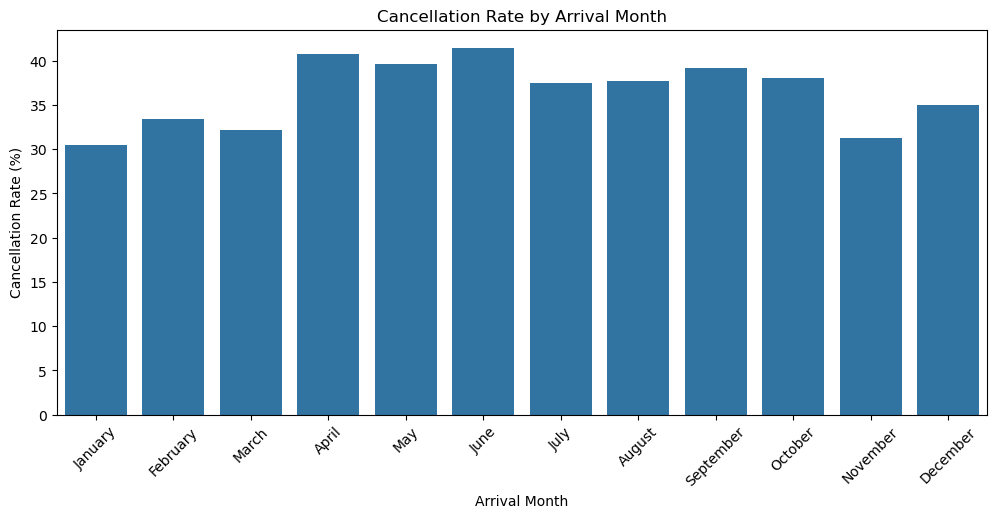

In [156]:
monthly_rate = (
    df.groupby('arrival_date_month')['is_canceled']
    .mean() * 100
).reindex(months)

plt.figure(figsize=(12,5))

sns.barplot(
    x=monthly_rate.index,
    y=monthly_rate.values
)

plt.title('Cancellation Rate by Arrival Month')
plt.xlabel('Arrival Month')
plt.ylabel('Cancellation Rate (%)')

plt.xticks(rotation=45)
plt.show()

### Observations 

- Cancellation rates vary across arrival months, indicating a possible seasonal pattern in booking cancellations. June has the highest cancellation rate at approximately 41.46%, while January has the lowest at approximately 30.48%. Cancellation rates are generally higher during the period from April to October, whereas relatively lower rates are observed during January to March and November.

### Multivariate Analysis 

In [157]:
corr_cols = [
    'is_canceled',
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

In [158]:
corr = df[corr_cols].corr()

In [159]:
corr

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
is_canceled,1.000000,0.293123,-0.001791,0.024765,0.060017,0.005048,-0.032491,-0.084793,0.110133,-0.057358,-0.144381,0.054186,0.047557,-0.195498,-0.234658
lead_time,0.293123,1.000000,0.085671,0.165799,0.119519,-0.037622,-0.020915,-0.124410,0.086042,-0.073548,0.000149,0.170084,-0.063077,-0.116451,-0.095712
stays_in_weekend_nights,-0.001791,0.085671,1.000000,0.498969,0.091871,0.045793,0.018483,-0.087239,-0.012775,-0.042715,0.063281,-0.054151,0.049342,-0.018554,0.072671
stays_in_week_nights,0.024765,0.165799,0.498969,1.000000,0.092976,0.044203,0.020191,-0.097245,-0.013992,-0.048743,0.096209,-0.002020,0.065237,-0.024859,0.068192
adults,0.060017,0.119519,0.091871,0.092976,1.000000,0.030447,0.018146,-0.146426,-0.006738,-0.107983,-0.051673,-0.008283,0.230641,0.014785,0.122884
children,0.005048,-0.037622,0.045793,0.044203,0.030447,1.000000,0.024030,-0.032859,-0.024730,-0.021072,0.048949,-0.033273,0.324854,0.056253,0.081745
babies,-0.032491,-0.020915,0.018483,0.020191,0.018146,0.024030,1.000000,-0.008943,-0.007501,-0.006550,0.083440,-0.010621,0.029186,0.037383,0.097889
is_repeated_guest,-0.084793,-0.124410,-0.087239,-0.097245,-0.146426,-0.032859,-0.008943,1.000000,0.082293,0.418056,0.012092,-0.022235,-0.134314,0.077090,0.013050
previous_cancellations,0.110133,0.086042,-0.012775,-0.013992,-0.006738,-0.024730,-0.007501,0.082293,1.000000,0.152728,-0.026993,0.005929,-0.065646,-0.018492,-0.048384
previous_bookings_not_canceled,-0.057358,-0.073548,-0.042715,-0.048743,-0.107983,-0.021072,-0.006550,0.418056,0.152728,1.000000,0.011608,-0.009397,-0.072144,0.047653,0.037824


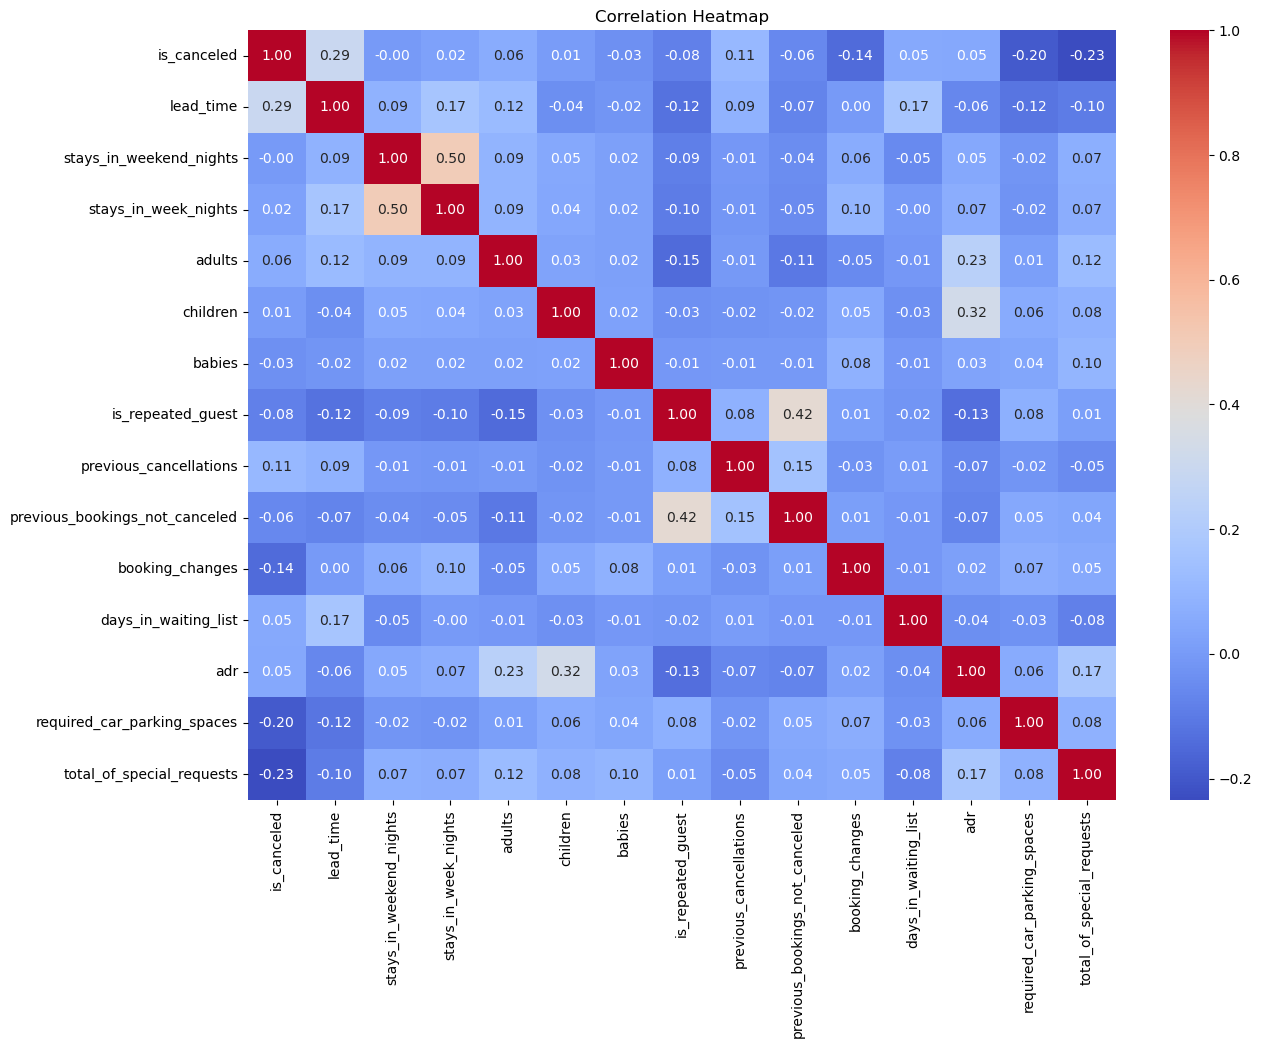

In [160]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [161]:
corr['is_canceled'].sort_values(ascending=False)

is_canceled                       1.000000
lead_time                         0.293123
previous_cancellations            0.110133
adults                            0.060017
days_in_waiting_list              0.054186
adr                               0.047557
stays_in_week_nights              0.024765
children                          0.005048
stays_in_weekend_nights          -0.001791
babies                           -0.032491
previous_bookings_not_canceled   -0.057358
is_repeated_guest                -0.084793
booking_changes                  -0.144381
required_car_parking_spaces      -0.195498
total_of_special_requests        -0.234658
Name: is_canceled, dtype: float64

### Observations 

- lead_time shows the strongest positive correlation with is_canceled (r ≈ 0.293), indicating that bookings made further in advance tend to be associated with higher cancellation likelihood. total_of_special_requests (r ≈ -0.235) and required_car_parking_spaces (r ≈ -0.195) show the strongest negative correlations with cancellation, suggesting that bookings with more special requests or parking requirements tend to be associated with lower cancellation. previous_cancellations shows a weak positive correlation (r ≈ 0.110), while several features such as children, stays_in_weekend_nights, and stays_in_week_nights show very weak or negligible linear correlations with cancellation.

## Key Business Insights 

1. High cancellation rate

- Approximately 37% of bookings are canceled, indicating that cancellations are a significant issue for the hotel and can create uncertainty in occupancy and revenue planning.

2. Long lead-time bookings are more likely to be canceled

- Bookings made further in advance show a higher cancellation tendency. The hotel could closely monitor long-lead-time bookings and consider appropriate confirmation or cancellation policies for them.

3. Cancellation behavior differs significantly by market segment

- Group bookings have a particularly high cancellation rate, while Direct and Corporate bookings have considerably lower rates. This suggests that cancellation policies and monitoring could be tailored according to market segment.

4. City Hotel has higher cancellation risk

- City Hotel bookings have a substantially higher cancellation rate than Resort Hotel bookings. Therefore, the two hotel types may require different cancellation-management and occupancy-planning strategies.

5. Customer type influences cancellation behavior

- Transient customers have the highest cancellation rate, whereas Group customers have the lowest. This indicates that customer type can be useful for identifying different cancellation-risk segments.

6. Cancellation behavior varies across countries

- There is considerable variation in cancellation rates among guest countries, with Portugal showing particularly high cancellation rates among the major countries in the dataset. This suggests that geographic/customer segmentation may be useful when managing cancellation risk.

7. Cancellation shows a seasonal pattern

- Cancellation rates vary by arrival month, with June having the highest rate (~41.5%) and January the lowest (~30.5%). Hotels can consider these seasonal patterns when forecasting occupancy and planning promotions or inventory.

8. Customer engagement is associated with lower cancellation

- Bookings with more special requests and required parking spaces tend to have lower cancellation rates. These variables may act as behavioral signals of booking commitment and could be useful in a cancellation prediction model.

### Final Conclusion

- Overall, cancellation behavior is influenced by booking characteristics, customer segments, hotel type, geography, and seasonality. The findings suggest that the hotel could benefit from identifying high-risk bookings early and applying targeted cancellation-management strategies rather than using the same approach for all bookings.